# Fraud Detection Analysis

This notebook uses the **PaySim** fraud dataset, which has readable transaction fields such as:

- `type`
- `amount`
- `nameOrig`
- `nameDest`
- `isFraud`
- `isFlaggedFraud`


## Problem framing

Fraud detection is an **imbalanced classification** problem:

- fraud is rare
- missing fraud is costly
- too many false positives create operational noise

For that reason, this notebook focuses on:

- precision-recall AUC
- recall
- precision
- F-beta score with beta > 1


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data import TARGET_COLUMN, load_paysim_sample, train_valid_test_split
from src.features import (
    LEAKAGE_COLUMNS,
    IDENTIFIER_COLUMNS,
    add_transaction_features,
    annotate_importance,
    build_feature_lists,
    describe_features,
    select_modeling_frame,
)
from src.modeling import (
    build_model_candidates,
    compare_models,
    compute_binary_metrics,
    extract_feature_importance,
    find_best_threshold,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42
BETA = 2.0


## 1. Load the dataset

The PaySim CSV is large, so the loader creates a practical modeling sample:

- keeps **all fraud rows**
- keeps a reproducible sample of non-fraud rows
- caches the sampled file in `data/processed`

This keeps the notebook usable on a normal laptop while preserving the fraud cases.


In [2]:
paysim_df, sample_metadata = load_paysim_sample()

pd.DataFrame([sample_metadata]).T.rename(columns={0: "value"})


,value
source_csv,/Users/trshwetha7/Desktop/Finance-Jupyternoteb...
total_rows,6362620
fraud_rows,8213
non_fraud_rows,6354407
sample_rows,135303
sample_fraud_rows,8213
sample_fraud_rate,0.0607
non_fraud_sampling_fraction,0.0200
loaded_from_cache,True


In [3]:
print(f"Sample shape: {paysim_df.shape}")
print(f"Sample fraud rate: {paysim_df[TARGET_COLUMN].mean():.4%}")

paysim_df.head()


Sample shape: (135303, 11)
Sample fraud rate: 6.0701%


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,303,PAYMENT,"7,795.7800",C680584454,0.0000,0.0000,M1175297496,0.0000,0.0000,0,0
1,380,CASH_OUT,"79,333.4700",C1195063264,"35,315.0000",0.0000,C50843589,"990,365.2500","1,069,698.8000",0,0
2,275,PAYMENT,"16,119.5400",C828380311,"164,957.0000","148,837.4500",M245237271,0.0000,0.0000,0,0
3,308,CASH_OUT,"113,180.5700",C313365451,"179,537.0000","66,356.4300",C1833099725,"7,804,973.0000","7,918,153.5000",0,0
4,139,CASH_OUT,"186,423.3600",C301715283,"2,332.0000",0.0000,C1914291223,"105,246.5400","291,669.9000",0,0


## 2. Data dictionary and quality checks

The dataset has meaningful field names, but not every field should be modeled directly:

- `nameOrig` and `nameDest` are raw identifiers, not generalizable business features
- the balance fields are excluded from modeling because the dataset documentation warns they can leak label information


In [4]:
describe_features(paysim_df.columns.tolist())


,feature,group,description
0,step,raw,Hour index in the simulation timeline.
1,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA..."
2,amount,raw,Transaction amount.
3,nameOrig,excluded,Dropped from modeling because raw account IDs ...
4,oldbalanceOrg,excluded,Excluded from modeling because the source data...
5,newbalanceOrig,excluded,Excluded from modeling because the source data...
6,nameDest,excluded,Dropped from modeling because raw account IDs ...
7,oldbalanceDest,excluded,Excluded from modeling because the source data...
8,newbalanceDest,excluded,Excluded from modeling because the source data...
9,isFraud,raw,Fraud label where 1 indicates fraud and 0 indi...


In [5]:
quality_checks = pd.DataFrame(
    {
        "missing_values": paysim_df.isna().sum(),
        "missing_pct": paysim_df.isna().mean() * 100,
    }
).sort_values("missing_values", ascending=False)

duplicate_count = paysim_df.duplicated().sum()
print(f"Duplicate rows in sample: {duplicate_count}")
quality_checks


Duplicate rows in sample: 0


,missing_values,missing_pct
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


## 3. Exploratory data analysis

Start by understanding the class imbalance and the transaction type mix.


/var/folders/8x/r23r85f11p7f99bc2gq2kxwh0000gn/T/ipykernel_60146/358088653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


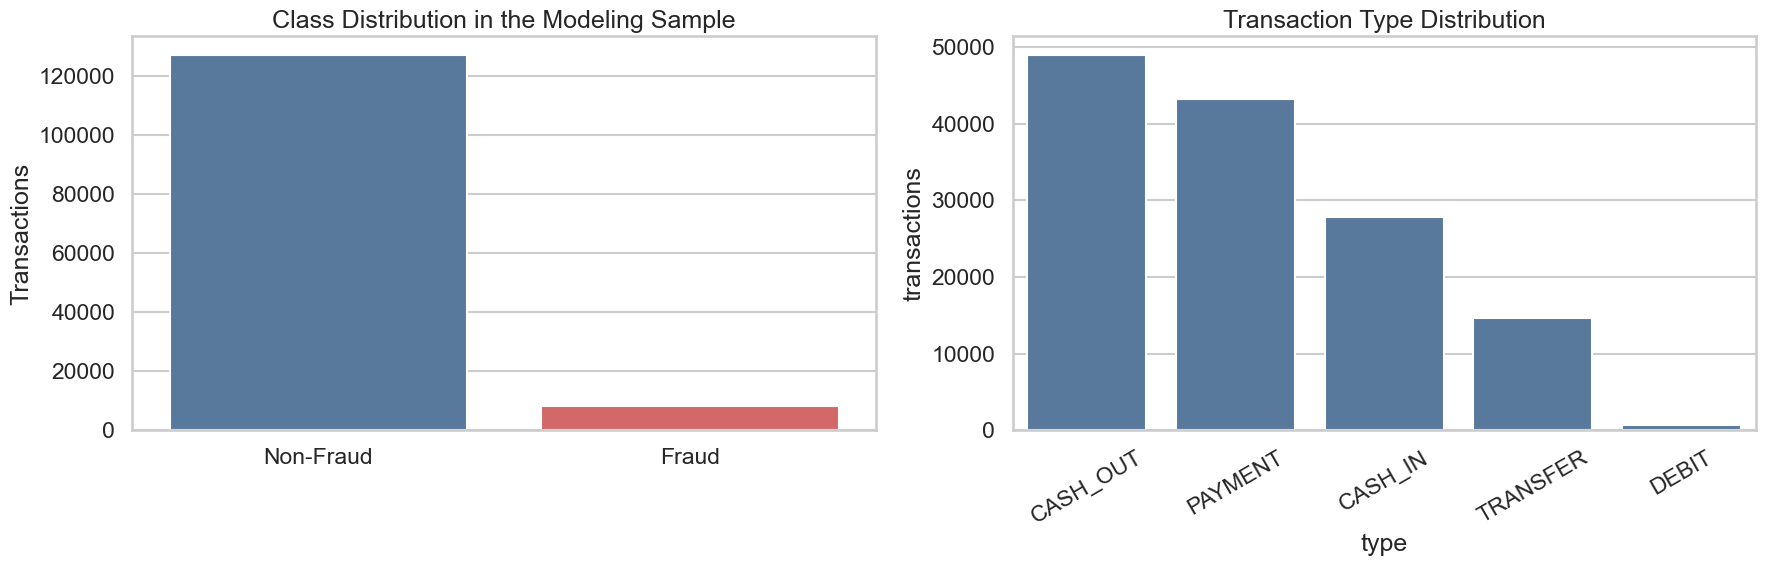

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

class_counts = paysim_df[TARGET_COLUMN].value_counts().sort_index()
sns.barplot(
    x=["Non-Fraud", "Fraud"],
    y=class_counts.values,
    palette=["#4C78A8", "#E45756"],
    ax=axes[0],
)
axes[0].set_title("Class Distribution in the Modeling Sample")
axes[0].set_ylabel("Transactions")

type_counts = paysim_df["type"].value_counts().reset_index()
type_counts.columns = ["type", "transactions"]
sns.barplot(data=type_counts, x="type", y="transactions", color="#4C78A8", ax=axes[1])
axes[1].set_title("Transaction Type Distribution")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()


/var/folders/8x/r23r85f11p7f99bc2gq2kxwh0000gn/T/ipykernel_60146/96802255.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


,type,transactions,fraud_rate,avg_amount
0,TRANSFER,14624,0.2802,"1,062,075.9557"
1,CASH_OUT,48934,0.0841,"282,443.4090"
2,CASH_IN,27799,0.0000,"168,936.0670"
3,DEBIT,767,0.0000,"4,839.6654"
4,PAYMENT,43179,0.0000,"13,084.5105"


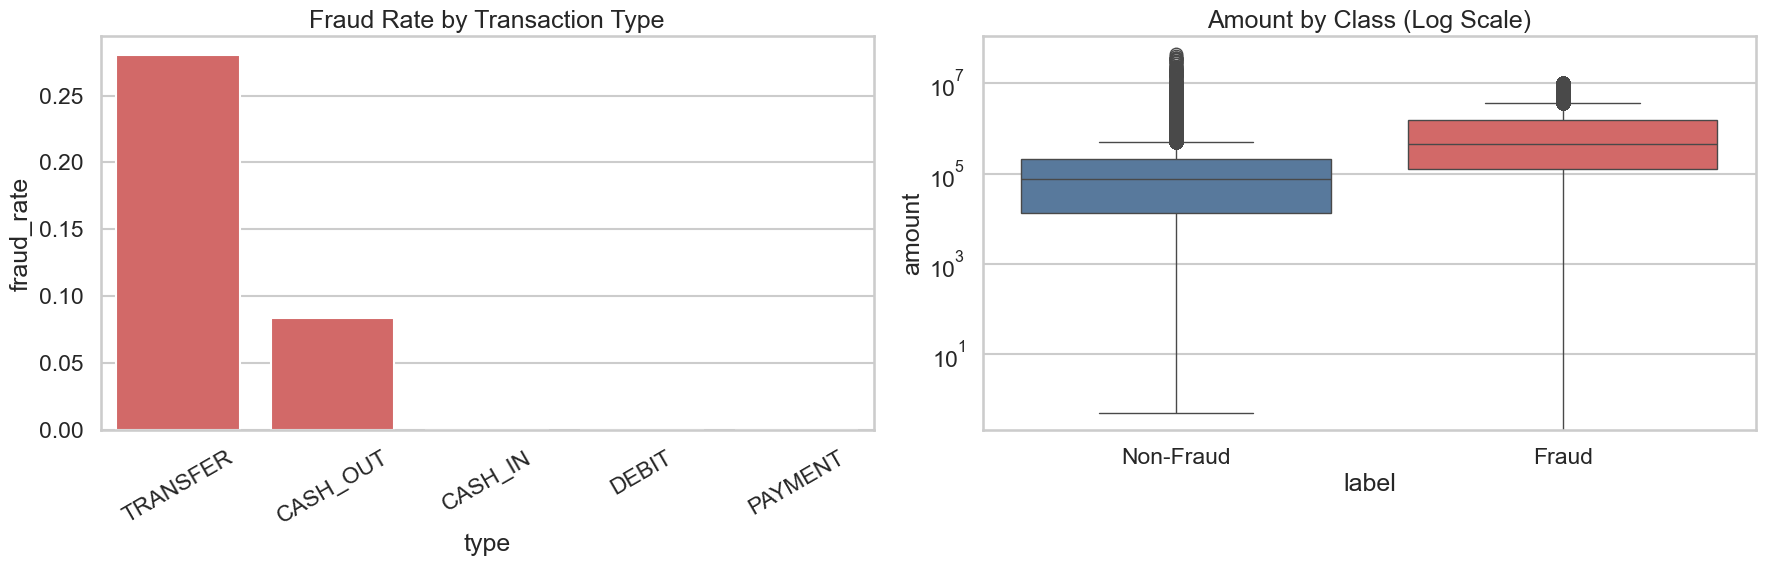

In [7]:
type_summary = (
    paysim_df.groupby("type")
    .agg(
        transactions=(TARGET_COLUMN, "size"),
        fraud_rate=(TARGET_COLUMN, "mean"),
        avg_amount=("amount", "mean"),
    )
    .sort_values("fraud_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=type_summary, x="type", y="fraud_rate", color="#E45756", ax=axes[0])
axes[0].set_title("Fraud Rate by Transaction Type")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(
    data=paysim_df.assign(label=paysim_df[TARGET_COLUMN].map({0: "Non-Fraud", 1: "Fraud"})),
    x="label",
    y="amount",
    palette=["#4C78A8", "#E45756"],
    ax=axes[1],
)
axes[1].set_yscale("log")
axes[1].set_title("Amount by Class (Log Scale)")

plt.tight_layout()
type_summary


/var/folders/8x/r23r85f11p7f99bc2gq2kxwh0000gn/T/ipykernel_60146/2965372826.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=destination_summary, x="destination_group", y="fraud_rate", palette=["#4C78A8", "#54A24B"], ax=axes[1])


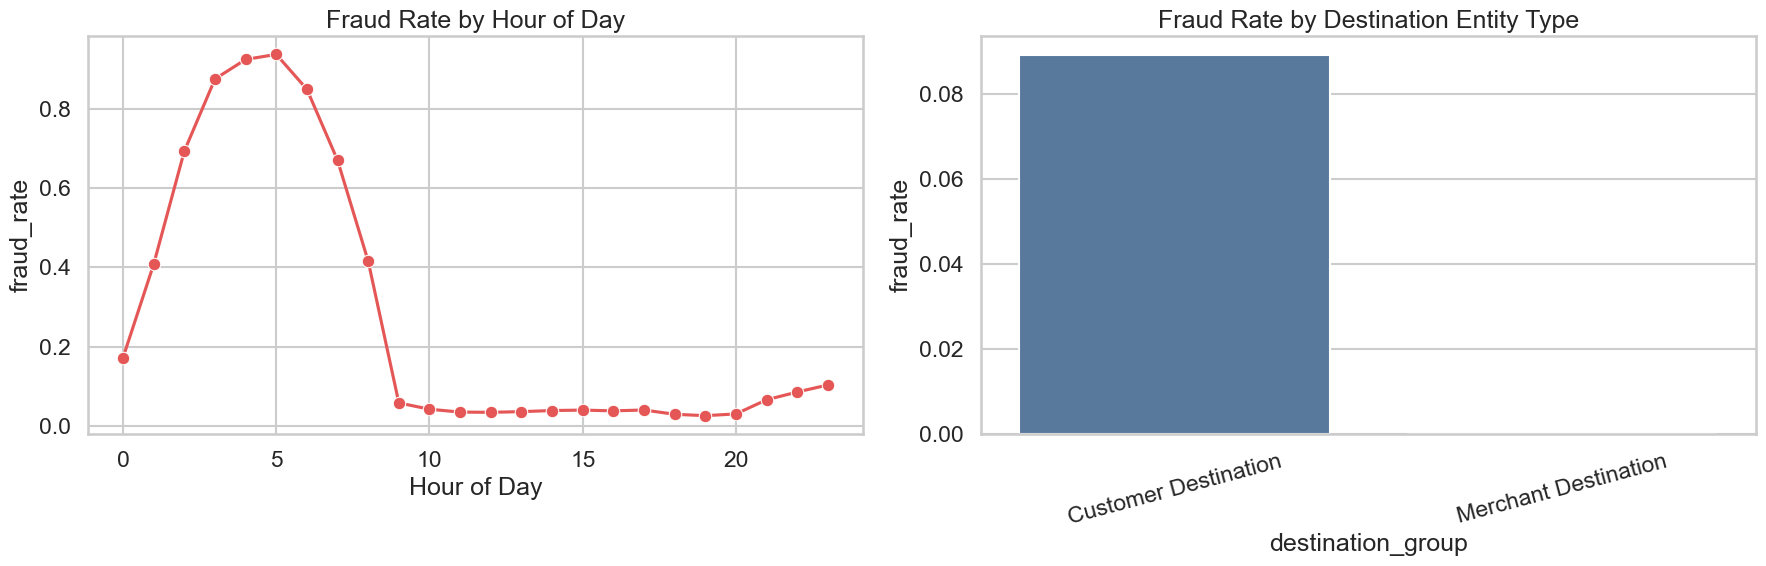

In [8]:
eda_df = add_transaction_features(paysim_df)

hourly_summary = (
    eda_df.groupby("hour_of_day")
    .agg(
        transactions=(TARGET_COLUMN, "size"),
        fraud_rate=(TARGET_COLUMN, "mean"),
    )
    .reset_index()
)

destination_summary = (
    eda_df.groupby("destination_is_merchant")[TARGET_COLUMN]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "fraud_rate", "count": "transactions"})
)
destination_summary["destination_group"] = destination_summary["destination_is_merchant"].map(
    {0: "Customer Destination", 1: "Merchant Destination"}
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.lineplot(data=hourly_summary, x="hour_of_day", y="fraud_rate", marker="o", color="#E45756", ax=axes[0])
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour of Day")

sns.barplot(data=destination_summary, x="destination_group", y="fraud_rate", palette=["#4C78A8", "#54A24B"], ax=axes[1])
axes[1].set_title("Fraud Rate by Destination Entity Type")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()


## 4. Feature engineering

The engineered features stay close to business meaning:

- hour and day features from `step`
- log-transformed amount
- large-amount flag
- customer versus merchant destination
- transfer or cash-out indicator


In [9]:
model_df = add_transaction_features(paysim_df)
engineered_columns = sorted(set(model_df.columns) - set(paysim_df.columns))

print("Engineered columns:", engineered_columns)
model_df[engineered_columns + [TARGET_COLUMN]].describe().T


Engineered columns: ['amount_over_200k', 'day_index', 'destination_is_customer', 'destination_is_merchant', 'hour_of_day', 'is_night', 'is_transfer_or_cash_out', 'log_amount', 'origin_is_customer']


,count,mean,std,min,25%,50%,75%,max
amount_over_200k,"135,303.0000",0.2877,0.4527,0.0000,0.0000,0.0000,1.0000,1.0000
day_index,"135,303.0000",10.8245,6.2797,1.0000,7.0000,11.0000,15.0000,31.0000
destination_is_customer,"135,303.0000",0.6809,0.4661,0.0000,0.0000,1.0000,1.0000,1.0000
destination_is_merchant,"135,303.0000",0.3191,0.4661,0.0000,0.0000,0.0000,1.0000,1.0000
hour_of_day,"135,303.0000",15.0850,4.6003,0.0000,12.0000,15.0000,19.0000,23.0000
is_night,"135,303.0000",0.0312,0.1737,0.0000,0.0000,0.0000,0.0000,1.0000
is_transfer_or_cash_out,"135,303.0000",0.4697,0.4991,0.0000,0.0000,0.0000,1.0000,1.0000
log_amount,"135,303.0000",10.9613,1.8855,0.0000,9.5820,11.3397,12.3280,17.5939
origin_is_customer,"135,303.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
isFraud,"135,303.0000",0.0607,0.2388,0.0000,0.0000,0.0000,0.0000,1.0000


In [10]:
feature_dictionary = describe_features(model_df.columns.tolist())
feature_dictionary


,feature,group,description
0,step,raw,Hour index in the simulation timeline.
1,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA..."
2,amount,raw,Transaction amount.
3,nameOrig,excluded,Dropped from modeling because raw account IDs ...
4,oldbalanceOrg,excluded,Excluded from modeling because the source data...
5,newbalanceOrig,excluded,Excluded from modeling because the source data...
6,nameDest,excluded,Dropped from modeling because raw account IDs ...
7,oldbalanceDest,excluded,Excluded from modeling because the source data...
8,newbalanceDest,excluded,Excluded from modeling because the source data...
9,isFraud,raw,Fraud label where 1 indicates fraud and 0 indi...


## 5. Define the modeling dataset

Two kinds of fields are intentionally removed before training:

- raw account identifiers
- balance columns flagged as leakage-prone by the dataset documentation


In [11]:
excluded_features = describe_features(IDENTIFIER_COLUMNS + LEAKAGE_COLUMNS)
excluded_features


,feature,group,description
0,nameOrig,excluded,Dropped from modeling because raw account IDs ...
1,nameDest,excluded,Dropped from modeling because raw account IDs ...
2,oldbalanceOrg,excluded,Excluded from modeling because the source data...
3,newbalanceOrig,excluded,Excluded from modeling because the source data...
4,oldbalanceDest,excluded,Excluded from modeling because the source data...
5,newbalanceDest,excluded,Excluded from modeling because the source data...


In [12]:
modeling_df = select_modeling_frame(model_df)
print(f"Modeling frame shape: {modeling_df.shape}")
modeling_df.head()


Modeling frame shape: (135303, 14)


,step,type,amount,isFraud,isFlaggedFraud,hour_of_day,day_index,is_night,log_amount,amount_over_200k,destination_is_merchant,destination_is_customer,origin_is_customer,is_transfer_or_cash_out
0,303,PAYMENT,"7,795.7800",0,0,15,13,0,8.9615,0,1,0,1,0
1,380,CASH_OUT,"79,333.4700",0,0,20,16,0,11.2814,0,0,1,1,1
2,275,PAYMENT,"16,119.5400",0,0,11,12,0,9.6878,0,1,0,1,0
3,308,CASH_OUT,"113,180.5700",0,0,20,13,0,11.6367,0,0,1,1,1
4,139,CASH_OUT,"186,423.3600",0,0,19,6,0,12.1358,0,0,1,1,1


## 6. Train, validation, and test splits

A stratified split keeps the fraud proportion consistent across subsets.


In [13]:
X_train, X_valid, X_test, y_train, y_valid, y_test = train_valid_test_split(
    modeling_df,
    target_col=TARGET_COLUMN,
    test_size=0.2,
    valid_size=0.2,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_valid), len(X_test)],
        "fraud_rate": [y_train.mean(), y_valid.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)
split_summary


,rows,fraud_rate
train,81181,0.0607
validation,27061,0.0607
test,27061,0.0607


## 7. Model training

Two models are compared:

- logistic regression as a strong linear baseline
- random forest as a nonlinear model with feature importance support


In [14]:
numeric_features, categorical_features = build_feature_lists(modeling_df, target_col=TARGET_COLUMN)
models = build_model_candidates(
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    random_state=RANDOM_STATE,
)

comparison_df, fitted_models = compare_models(
    models=models,
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    beta=BETA,
)

comparison_df


,model,roc_auc,pr_auc,precision,recall,f_beta,true_positives,false_positives,false_negatives,true_negatives
1,Random Forest,0.9686,0.8033,0.3956,0.8856,0.7098,"1,455.0000","2,223.0000",188.0000,"23,195.0000"
0,Logistic Regression,0.9301,0.5400,0.2750,0.8515,0.6000,"1,399.0000","3,688.0000",244.0000,"21,730.0000"


## 8. Threshold tuning

The default 0.50 threshold is rarely optimal for fraud problems.
Threshold tuning helps control the tradeoff between catching more fraud and generating false alerts.


In [15]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = fitted_models[best_model_name].pipeline
valid_scores = fitted_models[best_model_name].validation_scores

best_threshold, threshold_frame = find_best_threshold(
    y_true=y_valid,
    y_scores=valid_scores,
    beta=BETA,
    min_precision=0.10,
)

print(f"Selected model: {best_model_name}")
print(f"Best validation threshold: {best_threshold:.2f}")

threshold_frame.sort_values("f_beta", ascending=False).head(10)


Selected model: Random Forest
Best validation threshold: 0.61


,threshold,roc_auc,pr_auc,precision,recall,f_beta,true_positives,false_positives,false_negatives,true_negatives
60,0.6100,0.9686,0.8033,0.5424,0.8296,0.7501,"1,363.0000","1,150.0000",280.0000,"24,268.0000"
61,0.6200,0.9686,0.8033,0.5519,0.8217,0.7485,"1,350.0000","1,096.0000",293.0000,"24,322.0000"
59,0.6000,0.9686,0.8033,0.5298,0.8338,0.7480,"1,370.0000","1,216.0000",273.0000,"24,202.0000"
58,0.5900,0.9686,0.8033,0.5169,0.8393,0.7462,"1,379.0000","1,289.0000",264.0000,"24,129.0000"
62,0.6300,0.9686,0.8033,0.5592,0.8131,0.7455,"1,336.0000","1,053.0000",307.0000,"24,365.0000"
63,0.6400,0.9686,0.8033,0.5680,0.8058,0.7436,"1,324.0000","1,007.0000",319.0000,"24,411.0000"
67,0.6800,0.9686,0.8033,0.6395,0.7742,0.7429,"1,272.0000",717.0000,371.0000,"24,701.0000"
57,0.5800,0.9686,0.8033,0.5035,0.8430,0.7428,"1,385.0000","1,366.0000",258.0000,"24,052.0000"
64,0.6500,0.9686,0.8033,0.5795,0.7985,0.7424,"1,312.0000",952.0000,331.0000,"24,466.0000"
66,0.6700,0.9686,0.8033,0.6177,0.7809,0.7417,"1,283.0000",794.0000,360.0000,"24,624.0000"


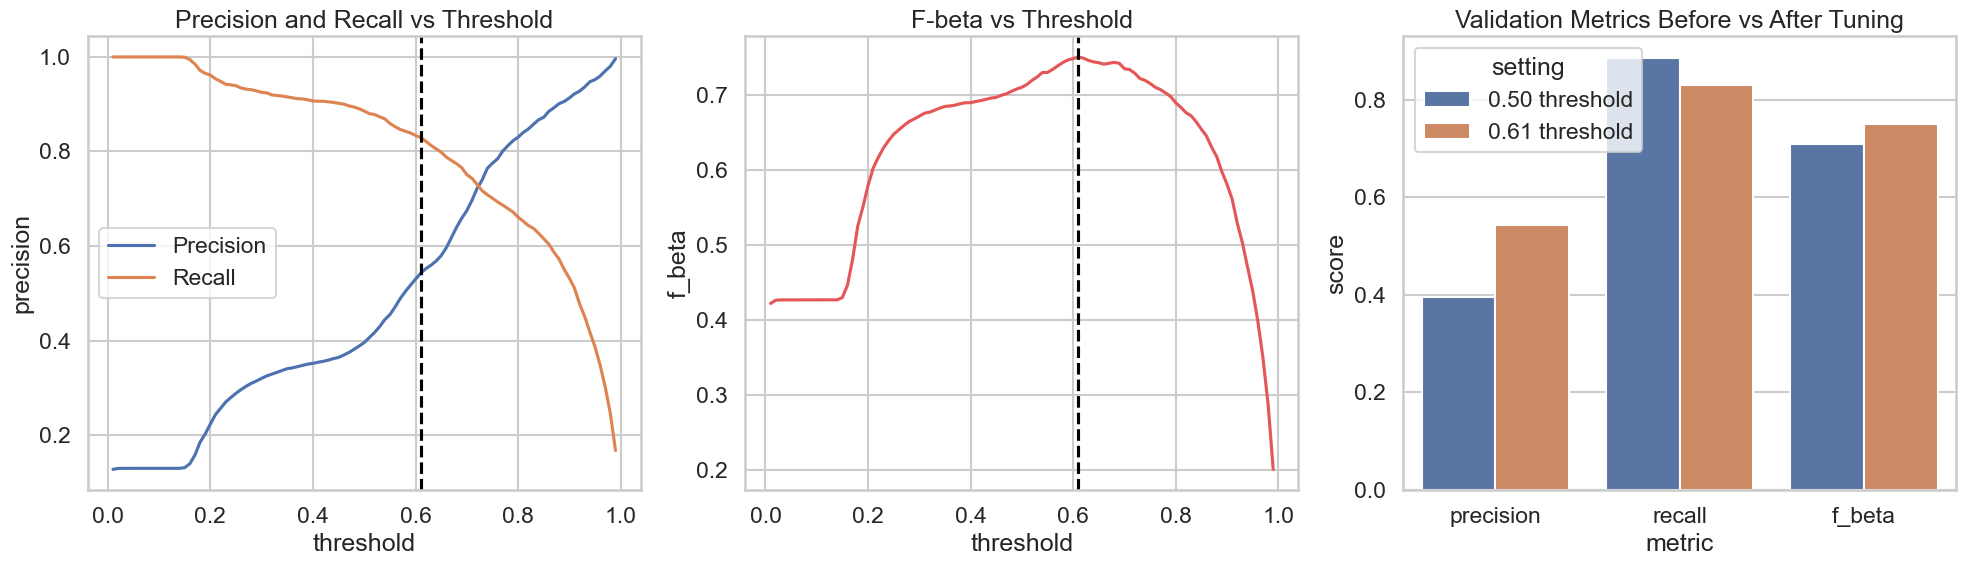

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.lineplot(data=threshold_frame, x="threshold", y="precision", ax=axes[0], label="Precision")
sns.lineplot(data=threshold_frame, x="threshold", y="recall", ax=axes[0], label="Recall")
axes[0].axvline(best_threshold, color="black", linestyle="--")
axes[0].set_title("Precision and Recall vs Threshold")

sns.lineplot(data=threshold_frame, x="threshold", y="f_beta", ax=axes[1], color="#E45756")
axes[1].axvline(best_threshold, color="black", linestyle="--")
axes[1].set_title("F-beta vs Threshold")

valid_metrics_default = compute_binary_metrics(y_valid, valid_scores, threshold=0.50, beta=BETA)
valid_metrics_tuned = compute_binary_metrics(y_valid, valid_scores, threshold=best_threshold, beta=BETA)
comparison_plot = pd.DataFrame(
    [
        {"setting": "0.50 threshold", **valid_metrics_default},
        {"setting": f"{best_threshold:.2f} threshold", **valid_metrics_tuned},
    ]
)
comparison_melted = comparison_plot.melt(
    id_vars="setting",
    value_vars=["precision", "recall", "f_beta"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=comparison_melted, x="metric", y="score", hue="setting", ax=axes[2])
axes[2].set_title("Validation Metrics Before vs After Tuning")

plt.tight_layout()


## 9. Final test set evaluation

The test set stays untouched until model selection and threshold tuning are complete.


In [17]:
test_scores = best_model.predict_proba(X_test)[:, 1]
test_metrics = compute_binary_metrics(
    y_true=y_test,
    y_scores=test_scores,
    threshold=best_threshold,
    beta=BETA,
)

pd.DataFrame([test_metrics]).T.rename(columns={0: "test_value"})


,test_value
roc_auc,0.9687
pr_auc,0.8068
precision,0.5539
recall,0.8138
f_beta,0.7439
true_positives,"1,337.0000"
false_positives,"1,077.0000"
false_negatives,306.0000
true_negatives,"24,341.0000"


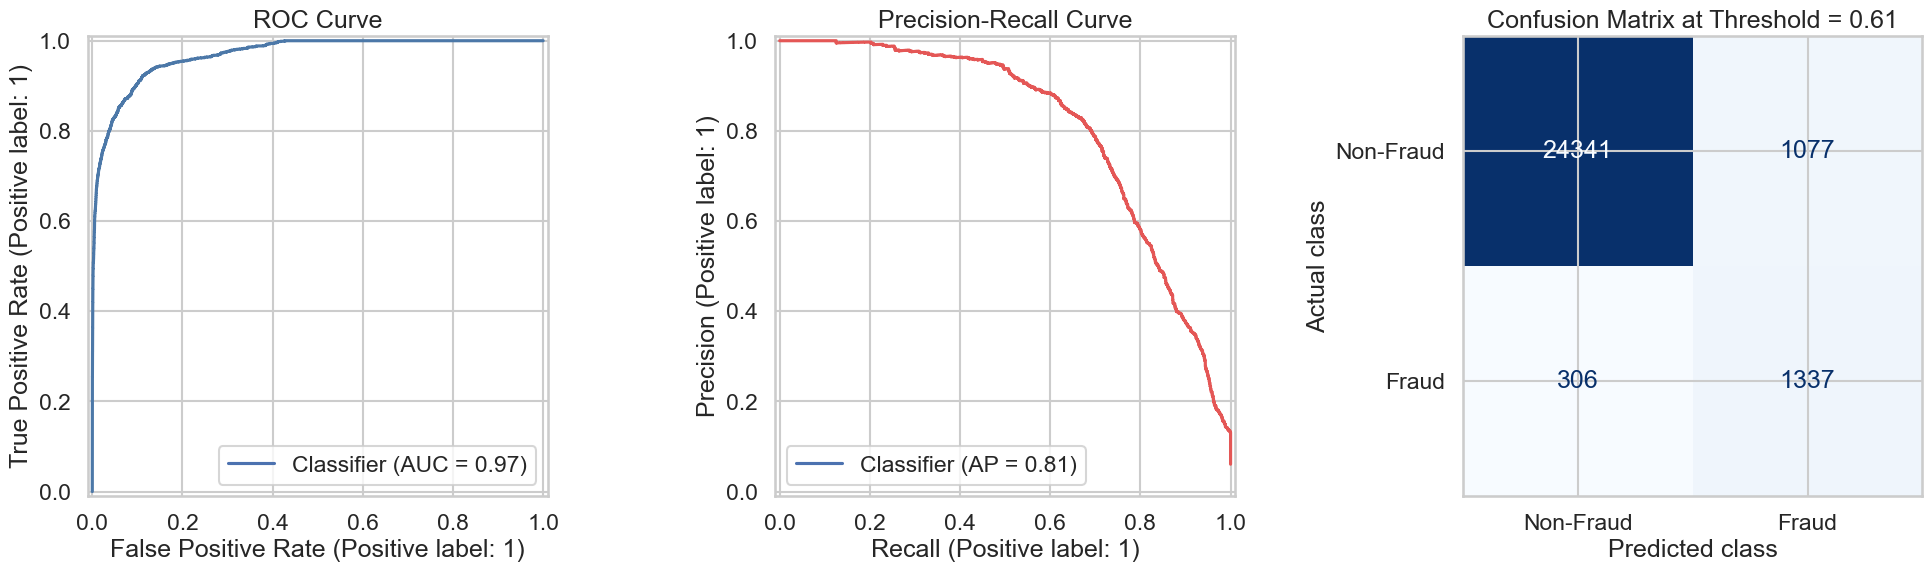

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

roc_display = RocCurveDisplay.from_predictions(
    y_test,
    test_scores,
    ax=axes[0],
)
roc_display.line_.set_color("#4C78A8")
axes[0].set_title("ROC Curve")

pr_display = PrecisionRecallDisplay.from_predictions(
    y_test,
    test_scores,
    ax=axes[1],
)
pr_display.line_.set_color("#E45756")
axes[1].set_title("Precision-Recall Curve")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    (test_scores >= best_threshold).astype(int),
    ax=axes[2],
    cmap="Blues",
    colorbar=False,
    display_labels=["Non-Fraud", "Fraud"],
)
axes[2].set_title(f"Confusion Matrix at Threshold = {best_threshold:.2f}")
axes[2].set_xlabel("Predicted class")
axes[2].set_ylabel("Actual class")

plt.tight_layout()


In [20]:
tn = int(test_metrics["true_negatives"])
fp = int(test_metrics["false_positives"])
fn = int(test_metrics["false_negatives"])
tp = int(test_metrics["true_positives"])

confusion_explanation = pd.DataFrame(
    [
        {"cell": "Top-left", "meaning": "Correctly predicted non-fraud", "count": tn},
        {"cell": "Top-right", "meaning": "Non-fraud predicted as fraud", "count": fp},
        {"cell": "Bottom-left", "meaning": "Fraud predicted as non-fraud", "count": fn},
        {"cell": "Bottom-right", "meaning": "Correctly predicted fraud", "count": tp},
    ]
)

confusion_explanation


,cell,meaning,count
0,Top-left,Correctly predicted non-fraud,24341
1,Top-right,Non-fraud predicted as fraud,1077
2,Bottom-left,Fraud predicted as non-fraud,306
3,Bottom-right,Correctly predicted fraud,1337


In [21]:
confusion_rate_summary = pd.DataFrame(
    [
        {"metric": "Recall (fraud caught)", "value": tp / (tp + fn) if (tp + fn) else 0.0},
        {"metric": "Precision (alerts that were truly fraud)", "value": tp / (tp + fp) if (tp + fp) else 0.0},
        {"metric": "False positive rate on normal transactions", "value": fp / (fp + tn) if (fp + tn) else 0.0},
        {"metric": "Miss rate on fraud transactions", "value": fn / (fn + tp) if (fn + tp) else 0.0},
    ]
)

confusion_rate_summary


,metric,value
0,Recall (fraud caught),0.8138
1,Precision (alerts that were truly fraud),0.5539
2,False positive rate on normal transactions,0.0424
3,Miss rate on fraud transactions,0.1862


How to read the confusion matrix:

- the rows are the **actual** class
- the columns are the **predicted** class
- the top-left cell is good because those are normal transactions correctly left alone
- the bottom-right cell is good because those are fraud cases correctly caught
- the top-right cell is the false-alarm count
- the bottom-left cell is the missed-fraud count

In this problem, the bottom-left cell is especially important because those are fraud cases the model failed to catch.


## 10. Model interpretation

The importance table below maps transformed model features back to readable source features.
That means a value such as `type_TRANSFER` is grouped under the base feature `type`,
rather than appearing as an unexplained model artifact.


In [22]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out().tolist()
importance_df = extract_feature_importance(best_model, feature_names)
annotated_importance_df = annotate_importance(importance_df)
annotated_importance_df.head(15)


,feature,base_feature,group,description,importance
0,num__is_transfer_or_cash_out,is_transfer_or_cash_out,engineered,Flag for transaction types most commonly assoc...,0.2187
1,num__amount,amount,raw,Transaction amount.,0.1280
2,num__log_amount,log_amount,engineered,Log-transformed amount using log1p to reduce s...,0.1087
3,num__step,step,raw,Hour index in the simulation timeline.,0.1020
4,num__hour_of_day,hour_of_day,engineered,"Hour of day derived from step, ranging from 0 ...",0.1010
5,cat__type_TRANSFER,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA...",0.0971
6,cat__type_TRANSFER,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA...",0.0971
7,cat__type_TRANSFER,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA...",0.0971
8,cat__type_TRANSFER,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA...",0.0971
9,cat__type_TRANSFER,type,raw,"Transaction type such as CASH_IN, CASH_OUT, PA...",0.0971


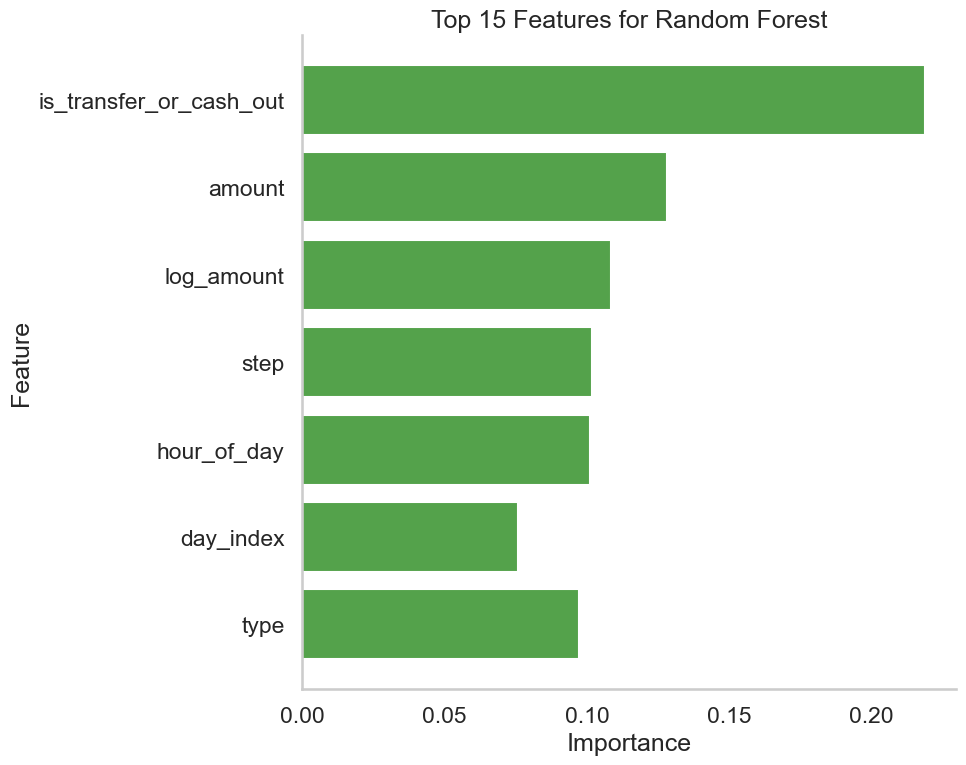

In [23]:
top_importance = annotated_importance_df.head(15).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_importance["base_feature"], top_importance["importance"], color="#54A24B")
ax.set_title(f"Top 15 Features for {best_model_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()


Interpretation notes:

- `type` tells us which transaction category is most predictive
- `amount` and `log_amount` capture size effects
- `hour_of_day` and `is_night` capture timing behavior
- destination and transfer indicators help explain where risky flows concentrate

On this chart, a larger bar means the model relied more on that feature when splitting transactions into fraud and non-fraud groups.
The importance value does **not** tell direction by itself. For example, a large importance for `type` means transaction category matters a lot,
not that every value of `type` increases fraud risk.


## 11. Export predictions

The scored test transactions can be exported for review or downstream analysis.


In [24]:
prediction_frame = X_test.copy()
prediction_frame["actual_class"] = y_test.values
prediction_frame["fraud_probability"] = test_scores
prediction_frame["predicted_class"] = (test_scores >= best_threshold).astype(int)
prediction_frame = prediction_frame.sort_values("fraud_probability", ascending=False)

output_path = PROJECT_ROOT / "data" / "processed" / "test_set_predictions.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
prediction_frame.to_csv(output_path, index=False)

print(f"Saved predictions to: {output_path}")
prediction_frame.head(10)


Saved predictions to: /Users/trshwetha7/Desktop/Finance-Jupyternotebook /data/processed/test_set_predictions.csv


,step,type,amount,isFlaggedFraud,hour_of_day,day_index,is_night,log_amount,amount_over_200k,destination_is_merchant,destination_is_customer,origin_is_customer,is_transfer_or_cash_out,actual_class,fraud_probability,predicted_class
98815,437,CASH_OUT,"3,200,270.2000",0,5,19,1,14.9787,1,0,1,1,1,1,0.9999,1
62235,600,CASH_OUT,"7,363,709.0000",0,0,26,1,15.8121,1,0,1,1,1,1,0.9999,1
22700,699,CASH_OUT,"2,763,398.2000",0,3,30,1,14.8320,1,0,1,1,1,1,0.9999,1
61044,434,CASH_OUT,"4,152,987.0000",0,2,19,1,15.2393,1,0,1,1,1,1,0.9999,1
57833,504,CASH_OUT,"3,018,810.8000",0,0,22,1,14.9204,1,0,1,1,1,1,0.9999,1
14912,625,CASH_OUT,"2,480,321.8000",0,1,27,1,14.7239,1,0,1,1,1,1,0.9999,1
52559,624,CASH_OUT,"10,000,000.0000",0,0,27,1,16.1181,1,0,1,1,1,1,0.9999,1
43224,625,CASH_OUT,"10,000,000.0000",0,1,27,1,16.1181,1,0,1,1,1,1,0.9999,1
132408,507,CASH_OUT,"7,239,987.0000",0,3,22,1,15.7951,1,0,1,1,1,1,0.9999,1
91906,554,CASH_OUT,"10,000,000.0000",0,2,24,1,16.1181,1,0,1,1,1,1,0.9999,1


## 12. Final takeaways

Key lessons from this analysis:

- readable feature names make the model easier to interpret
- excluding leakage-prone columns matters more than squeezing out a little extra score
- threshold tuning is part of the modeling problem, not an afterthought
- exporting scored transactions makes the workflow easier to inspect and extend
